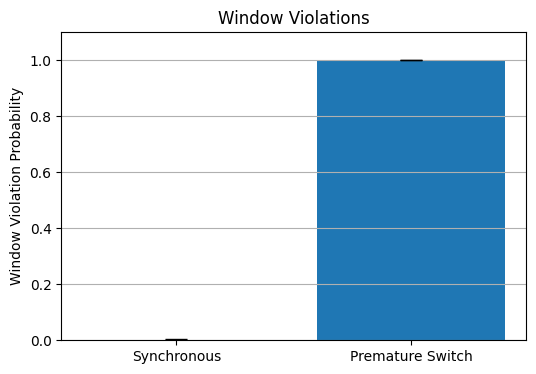

In [99]:
# {'N': 1000, 'window_violation_probability': 0.002, 'ci_lower': -0.0007690853363520596, 'ci_upper': 0.00476908533635206, 'mean_deadline_miss': 0.0, 'mean_interrupt': 0.0}
import matplotlib.pyplot as plt

labels = ["Synchronous", "Premature Switch"]

prob = [0.002, 1.0]

ci_lower = [-0.0007690853363520596, 1.0]
ci_upper = [0.00476908533635206, 1.0]

err_lower = [p - l for p, l in zip(prob, ci_lower)]
err_upper = [u - p for p, u in zip(prob, ci_upper)]

plt.figure(figsize=(6,4))

plt.bar(labels, prob, yerr=[err_lower, err_upper], capsize=8)

plt.ylabel("Window Violation Probability")
plt.title("Window Violations")

plt.ylim(0,1.1)

plt.grid(axis='y')

plt.show()

## Use Case: Single Inverted Pendulum on Cart
We consider a system of inverted pendulum on a cart, we assume the system operates in certain modes of operation to achieve the desired behaviour for that mode. 
Let the modes of operation be `m1` and `m2`, where the system operates at a sampling interval of `T=20ms` and `T=10ms` respectively. 
It is guaranteed that there exists a valid schedule $\tau$ that ensures the stability of the system by closing the control loop. 
From the spectral analysis, we were able to derive the robustness of the system to disturbance. We can state that there is a maximum consecutive deadline the system can
tolerate before becoming unstable for a given schedule $\tau$. 


$$\tau \vdash \langle n \rangle$$


where n is maximum consecutive deadline the system can miss. 

Sequence of operations: 
### Case 1: Pendulum operates in mode 1 for the entire life cycle 

h1 = 20ms
K1 = [-0.866502 	-1.688026 	-18.727439 	-3.592953]
n1 = 9

### Case 2: Aggressive mode for the entire life time

h2 = 10ms
K2 = [-23.770885, 	-21.232774, 	-88.144034, 	-18.446548]
n2 = 6

### Case 3: Premature switch
The system switches the mode of operation from m1 -> m2 at time t1 before the network configurations are ready.
The time taken for the network reconfig be $\delta_{nrc}$. We assume that the mode $m1$ has a valid schedule $\tau_1$
and `m2` has a valid schedule $\tau_2$. The premature switch of application mode results in an unstable system if
$\delta_{nrc} > n_2 \cdot h_2$

$$\delta_{nrc} \leq n_2 \cdot h_2$$

Alternatively, the safety condition:

$$\left\lceil \frac{\delta_{nrc}}{h_2} \right\rceil > n_2$$

### Case 4: Sync Switch
The system switches the mode of operation from m1 -> m2 at time t1 then the application and network switch modes only at synchronized time t2,  where t2 is the hypercycle of the sampling periods of modes.

### General Case
Let us assume a system with a set of modes of operations M = {m1, m2.. mn} then 

Found 4 state files:
  results/single_pendulum_cart/agg_mode_states.csv
  results/single_pendulum_cart/delayed_switch_states.csv
  results/single_pendulum_cart/normal_mode_states.csv
  results/single_pendulum_cart/sync_switch_states.csv


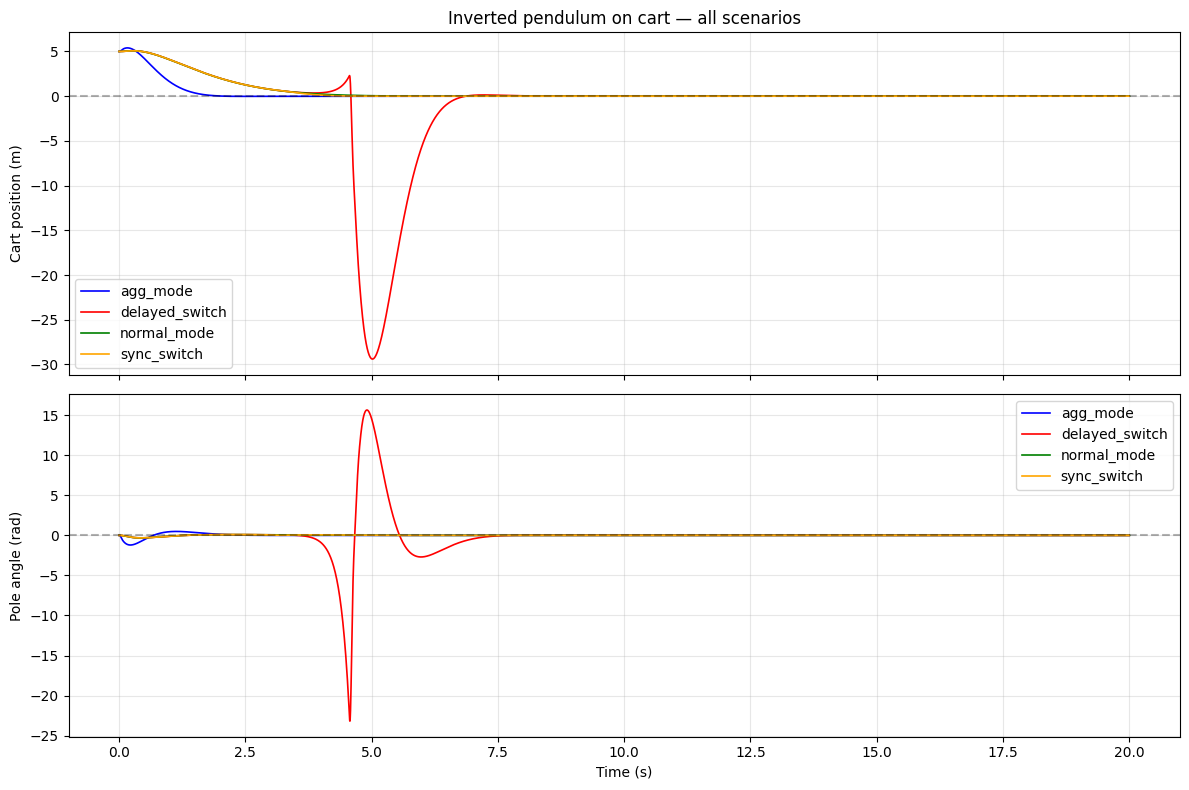

In [100]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Folders = "results/**/*_states.csv"

state_files = sorted(glob.glob(Folders, recursive=True))
print(f"Found {len(state_files)} state files:")
for f in state_files:
    print(f"  {f}")

colors = ['blue', 'red', 'green', 'orange', 'purple']

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for i, state_file in enumerate(state_files):
    df = pd.read_csv(state_file)
    label = state_file.split('/')[-1].replace('_states.csv', '')
    c = colors[i % len(colors)]
    
    axes[0].plot(df['t'], df['p'], label=label, color=c, linewidth=1.2)
    axes[1].plot(df['t'], df['theta'], label=label, color=c, linewidth=1.2)

axes[0].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[0].set_ylabel('Cart position (m)')
axes[0].legend()
axes[0].set_title('Inverted pendulum on cart — all scenarios')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Pole angle (rad)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/all_scenarios_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [77]:
# def independent_mode_plot(file):
#     # Read data from CSV file
#     df = pd.read_csv(file)  # Change path as needed
#     # Threshold for angle violation (15 degrees in radians)
#     THETA_THRESHOLD = 0.261799
    
    
#     # Status from Petri net validation (status column)
#     df['petri_violated'] = (df['status'] == 'violated').astype(int)
    
#     # Angle violation based on threshold
#     df['angle_violated'] = (df['max_theta'] > THETA_THRESHOLD).astype(int)
    
#     # Reshape data for box plot
#     misses = df['consecutive_misses'].unique()
    
#     petri_data = [df[df['consecutive_misses'] == m]['petri_violated'].values for m in misses]
#     angle_data = [df[df['consecutive_misses'] == m]['angle_violated'].values for m in misses]
    
#     # Box plot
#     fig, ax = plt.subplots(figsize=(12, 6))
    
#     positions_petri = np.array(misses) 
#     positions_angle = np.array(misses)
    
#     bp1 = ax.boxplot(petri_data, positions=positions_petri, widths=0.35, patch_artist=True,
#                      boxprops=dict(facecolor='blue', alpha=0.7),
#                      medianprops=dict(color='blue', linewidth=2),
#                      whiskerprops=dict(color='blue'),
#                      capprops=dict(color='blue'),
#                      flierprops=dict(markerfacecolor='blue', marker='o'))
    
#     bp2 = ax.boxplot(angle_data, positions=positions_angle, widths=0.35, patch_artist=True,
#                      boxprops=dict(facecolor='orange', alpha=0.7),
#                      medianprops=dict(color='orange', linewidth=2),
#                      whiskerprops=dict(color='orange'),
#                      capprops=dict(color='orange'),
#                      flierprops=dict(markerfacecolor='orange', marker='o'))
    
#     ax.set_xlabel('Consecutive Misses', fontsize=12)
#     ax.set_ylabel('Violated (1) / Safe (0)', fontsize=12)
#     ax.set_title('Petri Net Status vs Angle Violation', fontsize=14)
#     ax.set_xticks(misses)
#     ax.set_yticks([0, 1])
#     ax.set_yticklabels(['Safe', 'Violated'])
#     ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Petri Net Status', 'Angle Violation (θ > 15°)'])
#     ax.grid(True, axis='y', alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()

#     print(f"Petri net first violation: {df[df['petri_violated'] == 1]['consecutive_misses'].min()} misses")
#     print(f"Angle first violation: {df[df['angle_violated'] == 1]['consecutive_misses'].min()} misses")
import matplotlib.ticker as mticker
def independent_mode_plot(file, S_app):
    df = pd.read_csv(file)
    THETA_THRESHOLD = 0.261799

    df['petri_violated'] = (df['status'] == 'violated').astype(int)
    df['angle_violated'] = (df['max_theta'] > THETA_THRESHOLD).astype(int)

    PETRI_COLOR = '#0072B2'
    SIM_COLOR   = '#D55E00'

    misses = sorted(df['consecutive_misses'].unique())
    petri_vals = [df[df['consecutive_misses'] == m]['petri_violated'].max() for m in misses]
    angle_vals = [df[df['consecutive_misses'] == m]['angle_violated'].max() for m in misses]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.step(misses, petri_vals, where='post', color=PETRI_COLOR,
            linewidth=2.5, label='Petri Net Status')
    ax.step(misses, angle_vals, where='post', color=SIM_COLOR,
            linewidth=2.5, linestyle='--', label='Simulator ($\\theta > 15°$)')

    # Last safe point of Petri net = S_app boundary
    last_safe = max((m for m, v in zip(misses, petri_vals) if v == 0), default=None)

    if last_safe is not None:
        ax.axvline(x=last_safe, color='grey', alpha=0.5,
                   linestyle=':', linewidth=1.5)
        ax.annotate(
            f'$\\mathcal{{S}}_{{\\mathrm{{app}}}} = {S_app}$',
            xy=(last_safe, 0.5),
            xytext=(last_safe - 1.2, 0.6),
            arrowprops=dict(arrowstyle='->', color='grey'),
            fontsize=10,
            color='grey'
        )

    ax.set_xlabel('Network Schedule Consecutive Misses $\mathcal{S}_\mathrm{net}$', fontsize=12)
    ax.set_ylabel('Status', fontsize=12)
    ax.set_title('Petri Net Status vs Angle Violation for mode $\pi_1$', fontsize=13)
    ax.set_xticks(misses)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Safe', 'Violated'], fontsize=11)
    ax.set_ylim(-0.1, 1.3)
    ax.legend(fontsize=11)
    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Petri net first violation: "
          f"{next((m for m, v in zip(misses, petri_vals) if v == 1), None)} misses")
    print(f"Angle first violation:     "
          f"{next((m for m, v in zip(misses, angle_vals) if v == 1), None)} misses")
    

<>:91: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:93: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:91: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:93: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/pz/d1g_pynn2698jdxltndvqcn00000gn/T/ipykernel_60540/784680515.py:91: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('Network Schedule Consecutive Misses $\mathcal{S}_\mathrm{net}$', fontsize=12)
/var/folders/pz/d1g_pynn2698jdxltndvqcn00000gn/T/ipykernel_6

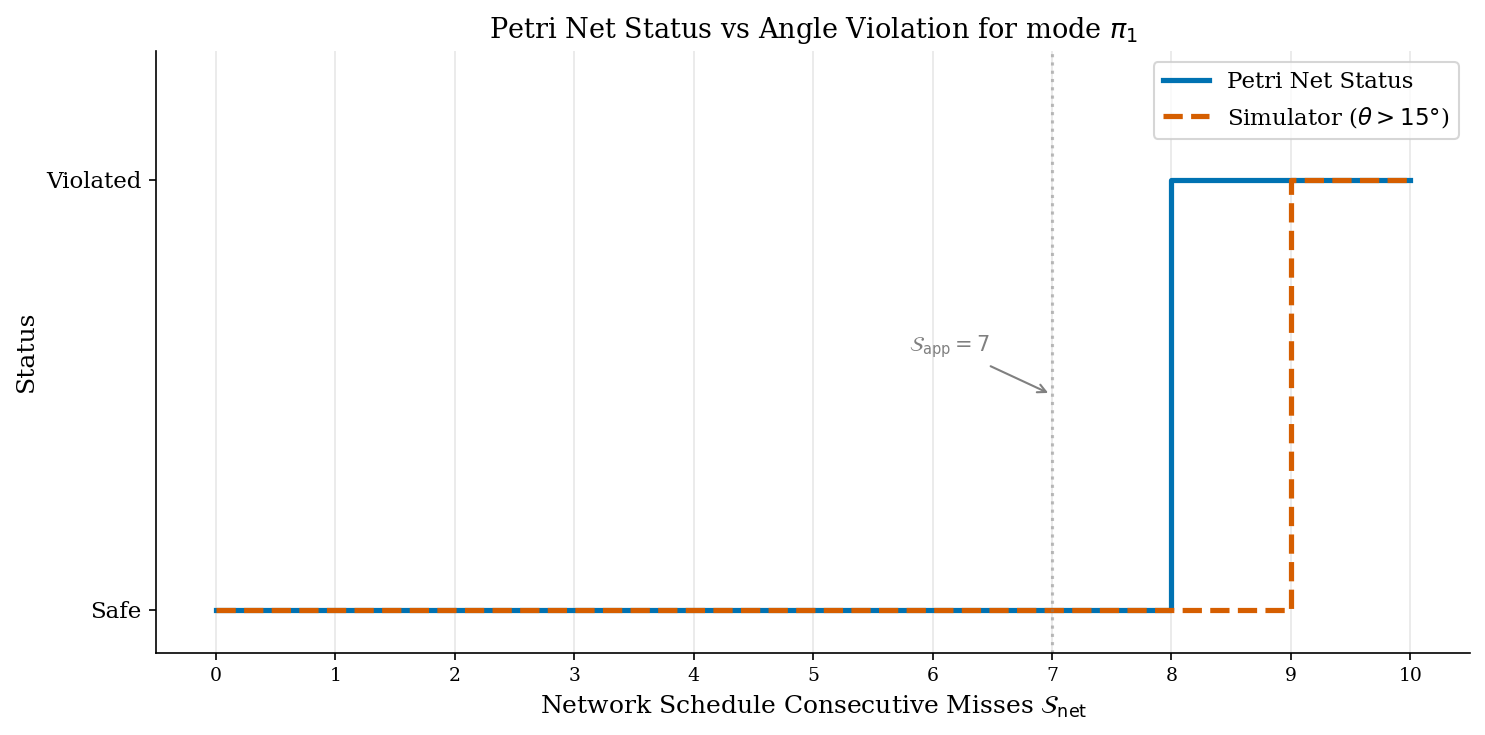

Petri net first violation: 8 misses
Angle first violation:     9 misses


In [78]:
independent_mode_plot('benchmark/pattern_results_20260505_221313.csv', 7)

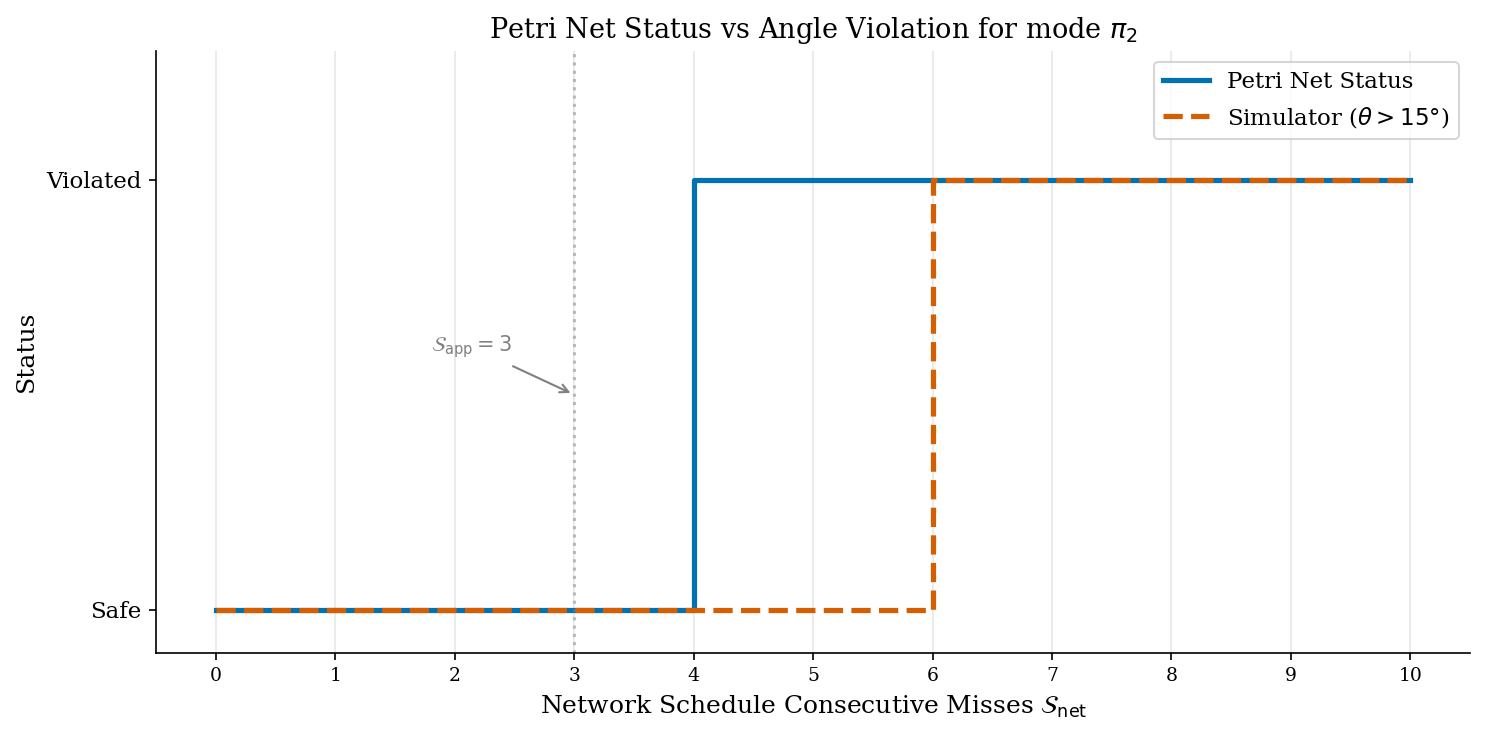

Petri net first violation: 4 misses
Angle first violation:     6 misses


In [75]:
# Mode 2
independent_mode_plot('benchmark/pattern_results_20260505_222156.csv', 3)

In [87]:
# Delta sweep plot (Section 6.3)
# Two CSV files: different transition behaviors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_mode_switch(file1, file2):
    col_names = ['delta', 'status', 'last_hit', 'first_new_hit', 'measured_window', 'max_theta']
    
    df1 = pd.read_csv(file1, skiprows=1, header=None, names=col_names)
    df2 = pd.read_csv(file2, skiprows=1, header=None, names=col_names)
    
    theta_max = np.deg2rad(15)  # 0.2618 rad
    delta_sufficient = 0.030    # min{S_app_1*p_1, S_app_2*p_2} = min{140, 30} = 30ms
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot both curves
    for df, label, color, marker in [
        (df1, 'm1 to m2', 'tab:blue', 'o'),
        (df2, 'm2 to m1', 'tab:red', 's')
    ]:
        sat = df[df['status'] == 'satisfied']
        vio = df[df['status'] == 'violated']
        
        ax.plot(df['measured_window'] * 1000, df['max_theta'], color=color, linewidth=2, label=label, zorder=2)
        ax.scatter(sat['measured_window'] * 1000, sat['max_theta'], color='green', marker=marker, 
                   s=30, zorder=3, edgecolors='none')
        ax.scatter(vio['measured_window'] * 1000, vio['max_theta'], color='red', marker=marker, 
                   s=30, zorder=3, edgecolors='none')
    
    # Sufficient condition boundary
    ax.axvline(delta_sufficient * 1000, color='black', linestyle='--', linewidth=1.5,
               label=f'Sufficient condition ({delta_sufficient*1000:.0f} ms)')
    
    # Theta threshold
    ax.axhline(theta_max, color='gray', linestyle=':', linewidth=1.5,
               label=f'$\\theta_{{max}}$ = 15° ({theta_max:.4f} rad)')
    
    ax.set_xlabel(r'Reconfiguration delay $\mathcal{T}_{i \to j}$ (ms)', fontsize=12)
    ax.set_ylabel('max $|\\theta|$ (rad)', fontsize=12)
    ax.set_title('Angle deviation vs network reconfiguration delay', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 260)
    
    plt.tight_layout()
    plt.show()

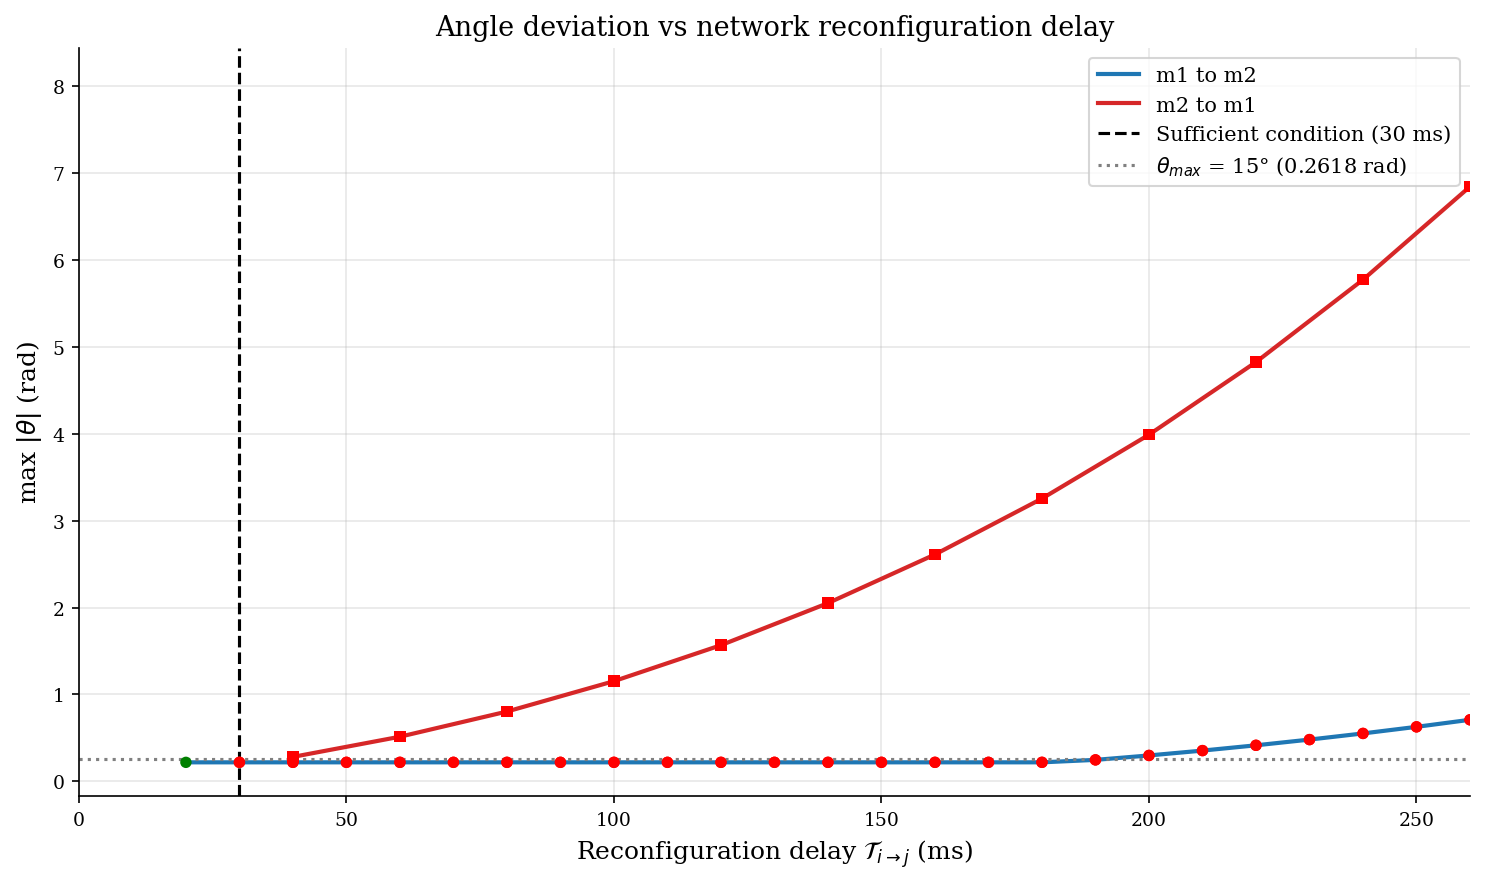

In [88]:
# Best case switch
# 
# file1='benchmark/delta_sweep_20260409_113414.csv'
# file2='benchmark/delta_sweep_20260409_113613.csv'

file1='benchmark/delta_sweep_20260511_042051.csv'
file2='benchmark/delta_sweep_20260511_042339.csv'

plot_mode_switch(file1, file2)

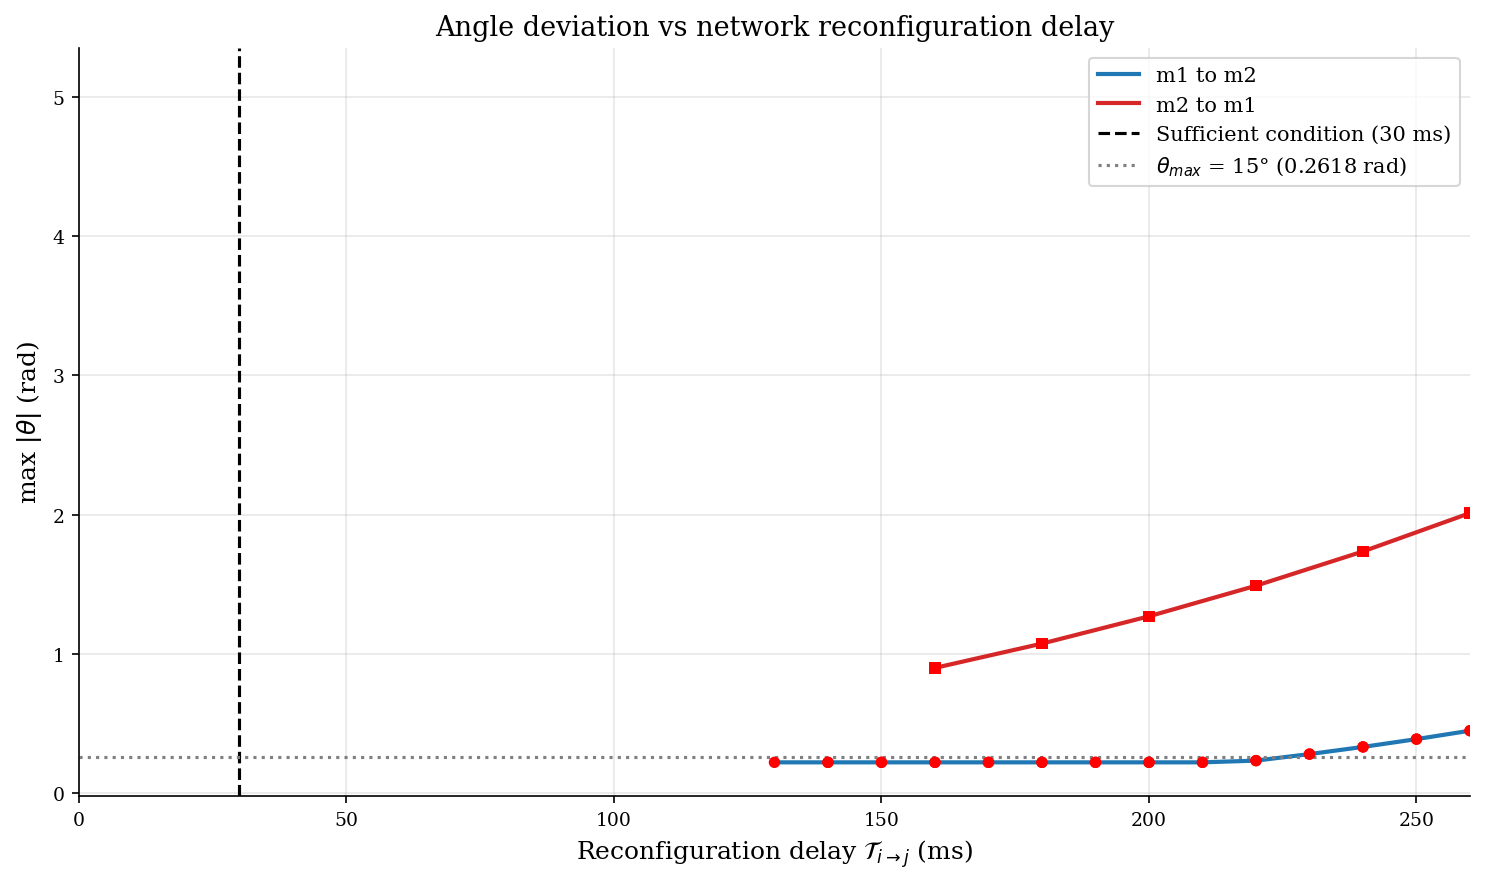

In [89]:
# Worst case switch
file1='benchmark/delta_sweep_20260409_114250.csv'
file2='benchmark/delta_sweep_20260409_114433.csv'

# file1='benchmark/delta_sweep_20260511_053321.csv'
# file2='benchmark/delta_sweep_20260511_053027.csv'

plot_mode_switch(file1, file2)

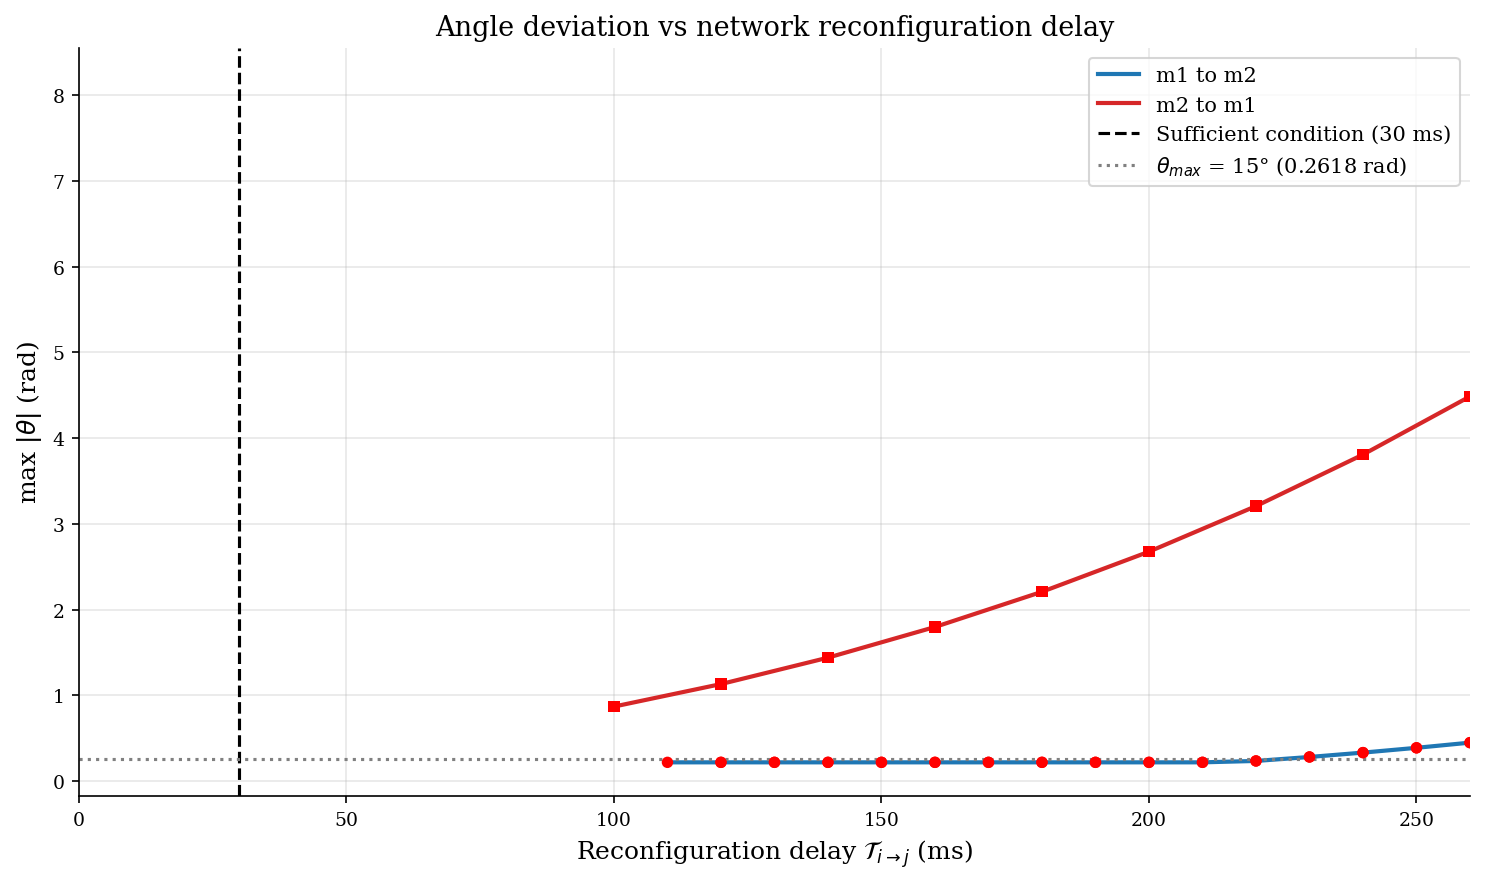

In [86]:
# Intermediate switch
file1='benchmark/delta_sweep_20260518_042954.csv'
# file2='benchmark/delta_sweep_20260518_043229.csv'
file2='benchmark/delta_sweep_20260518_201059.csv'

plot_mode_switch(file1, file2)

In [35]:
# Switch time sweep plot (Section 6.4.3)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
# def plot_switch_time_vs_angle(file):
#     df = pd.read_csv(file)
#     THRESHOLD = 0.261799

#     df['window_ms'] = (df['measured_window'] * 1000).round(0).astype(int)
#     df_agg = (df.groupby(['hit_index', 'window_ms'], as_index=False)['max_theta']
#                 .mean())

#     # Wong-safe palette, one colour per hit index
#     COLORS = [
#         '#0072B2', '#D55E00', '#009E73', '#E69F00',
#         '#56B4E9', '#CC79A7', '#F0E442', '#000000',
#         '#882255', '#44AA99'
#     ]

#     hit_indices = sorted(df_agg['hit_index'].unique())

#     fig, ax = plt.subplots(figsize=(11, 6))

#     for i, hit in enumerate(hit_indices):
#         subset = df_agg[df_agg['hit_index'] == hit].sort_values('window_ms')
#         ax.plot(
#             subset['window_ms'],
#             subset['max_theta'],
#             color=COLORS[i % len(COLORS)],
#             linewidth=1.8,
#             marker='o',
#             markersize=4,
#             label=f'Hit \#{hit}'
#         )

#     # Threshold line
#     ax.axhline(
#         THRESHOLD,
#         color='black',
#         linestyle='--',
#         linewidth=1.5,
#         label=r'Safety threshold $|\theta| = 15°$'
#     )

#     # Shade the violated region
#     ax.axhspan(
#         THRESHOLD,
#         1,
#         alpha=0.06,
#         color='#D55E00',
#         label='Violated region'
#     )

#     ax.set_xlabel(
#         r'Transition window $\mathcal{T}_{2 \to 1}$ (ms)', fontsize=12
#     )
#     ax.set_ylabel(r'max $|\theta|$ (rad)', fontsize=12)
#     ax.set_title(
#         r'Peak $|\theta|$ as a function of $\mathcal{T}_{2 \to 1}$ '
#         r'and switch timing',
#         fontsize=13
#     )

#     ax.set_xlim(left=0)
#     ax.set_ylim(0, 1.0)

#     # Sufficient condition boundary
#     ax.axvline(
#         30,
#         color='black',
#         linestyle=':',
#         linewidth=2,
#         label=r'Sufficient condition $\mathcal{T}_{2 \to 1} = 30$ ms'
#     )
#     ax.legend(
#         fontsize=9,
#         ncol=2,
#         loc='upper left',
#         framealpha=0.9
#     )
#     ax.grid(True, alpha=0.25)

#     plt.tight_layout()
#     plt.savefig('/Users/srindhikrishna/myworks/thesis/thesis-report/scientific-thesis-template-main/figures/switch_time_vs_angle_from_mode2.pdf', dpi=300, bbox_inches='tight')
#     plt.show()

#     # Print the critical window per hit index
#     print("First violating window per hit index:")
#     for hit in hit_indices:
#         subset = df_agg[df_agg['hit_index'] == hit]
#         first = subset[subset['max_theta'] > THRESHOLD]['window_ms'].min()
#         print(f"  Hit #{hit:2d}: {first} ms")
def plot_switch_time_vs_angle(file):
    df = pd.read_csv(file)
    threshold = 0.261799
    
    # Pivot to 2D grid: rows=hit_index, cols=delta
    pivot = df.pivot_table(index='hit_index', columns='measured_window', values='max_theta')
    
    fig, (ax1) = plt.subplots(1, 1, figsize=(15, 5))
    
    im = ax1.imshow(pivot.values, aspect='auto', cmap='YlOrRd',
                    extent=[pivot.columns.min()*1000, pivot.columns.max()*1000,
                            pivot.index.max()+0.5, pivot.index.min()-0.5])
    violations = df[df['max_theta'] > threshold]

    ax1.scatter(
        violations['measured_window'] * 1000,
        violations['hit_index'],
        color='black',
        marker='x',
        s=40,
        label='Violation'
    )
    
    ax1.legend(loc='lower right', fontsize=9)
    ax1.set_xlabel('$\mathcal{T}_{i \to j}$ (ms)', fontsize=12)
    ax1.set_ylabel('Switch after hit #', fontsize=12)
    ax1.set_title('max $|\\theta|$ vs switch timing and $\\delta$', fontsize=13)
    ax1.set_yticks(pivot.index)
    
    # Sufficient condition boundary
    ax1.axvline(30, color='black', linestyle='--', linewidth=2, label='Sufficient cond.')
    ax1.legend(loc='lower right', fontsize=9)
    
    cbar = fig.colorbar(im, ax=ax1)
    cbar.set_label('max $|\\theta|$ (rad)', fontsize=11)
    
    # for delta_val, color, ls in [(0.03, 'green', '-'), (0.10, 'tab:orange', '--'), 
    #                                (0.20, 'tab:red', '-.'), (0.25, 'darkred', ':')]:
    #     subset = df[np.isclose(df['measured_window'], delta_val)]
    #     if len(subset) > 0:
    #         ax2.plot(subset['hit_index'], subset['max_theta'], 
    #                  marker='o', color=color, linestyle=ls, linewidth=1.5, markersize=5,
    #                  label=f'$\\delta$={delta_val*1000:.0f}ms')
    
    # ax2.set_xlabel('Switch after hit #', fontsize=12)
    # ax2.set_ylabel('max $|\\theta|$ (rad)', fontsize=12)
    # ax2.set_title('Peak $|\\theta|$ vs switch timing', fontsize=13)
    # ax2.legend(fontsize=10)
    # ax2.grid(True, alpha=0.3)
    # ax2.set_xticks(range(1, 11))
    
    plt.tight_layout()
    plt.show()

<>:118: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:118: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/pz/d1g_pynn2698jdxltndvqcn00000gn/T/ipykernel_60540/702935000.py:118: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax1.set_xlabel('$\mathcal{T}_{i \to j}$ (ms)', fontsize=12)


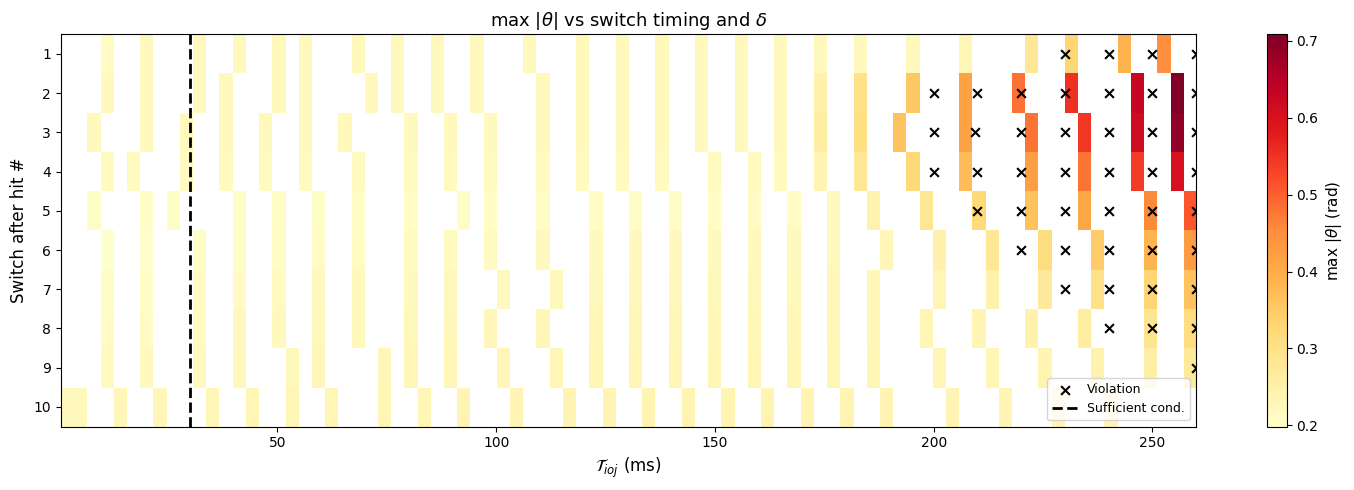

In [36]:
plot_switch_time_vs_angle('benchmark/switch_time_sweep_20260506_145713.csv')

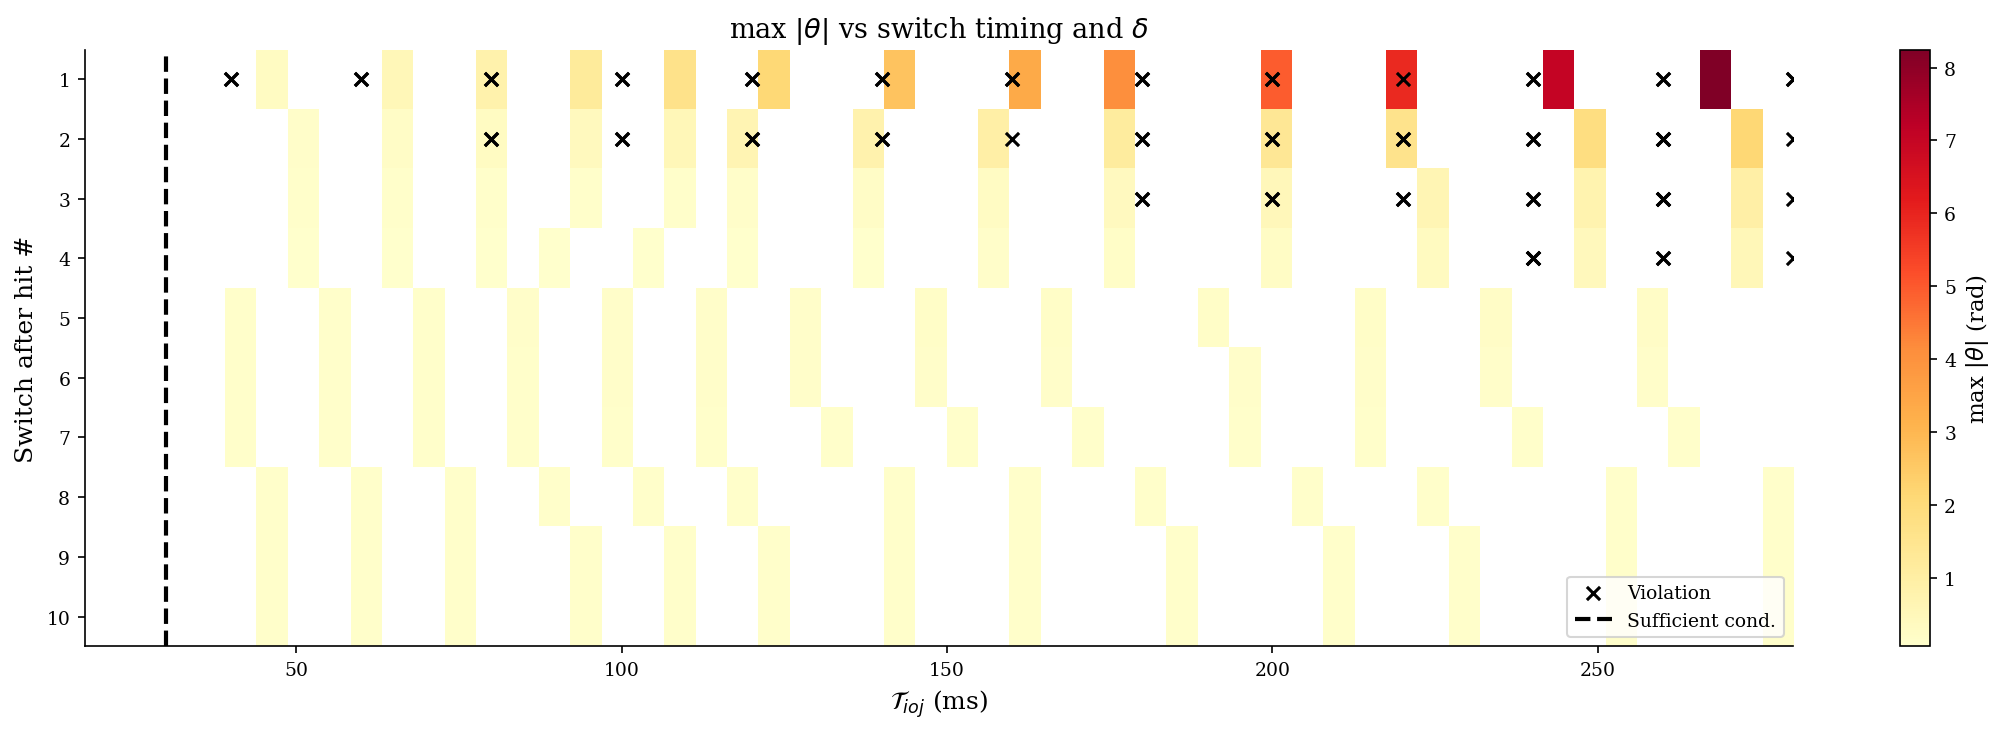

In [43]:
plot_switch_time_vs_angle('benchmark/switch_time_sweep_20260409_154707.csv')

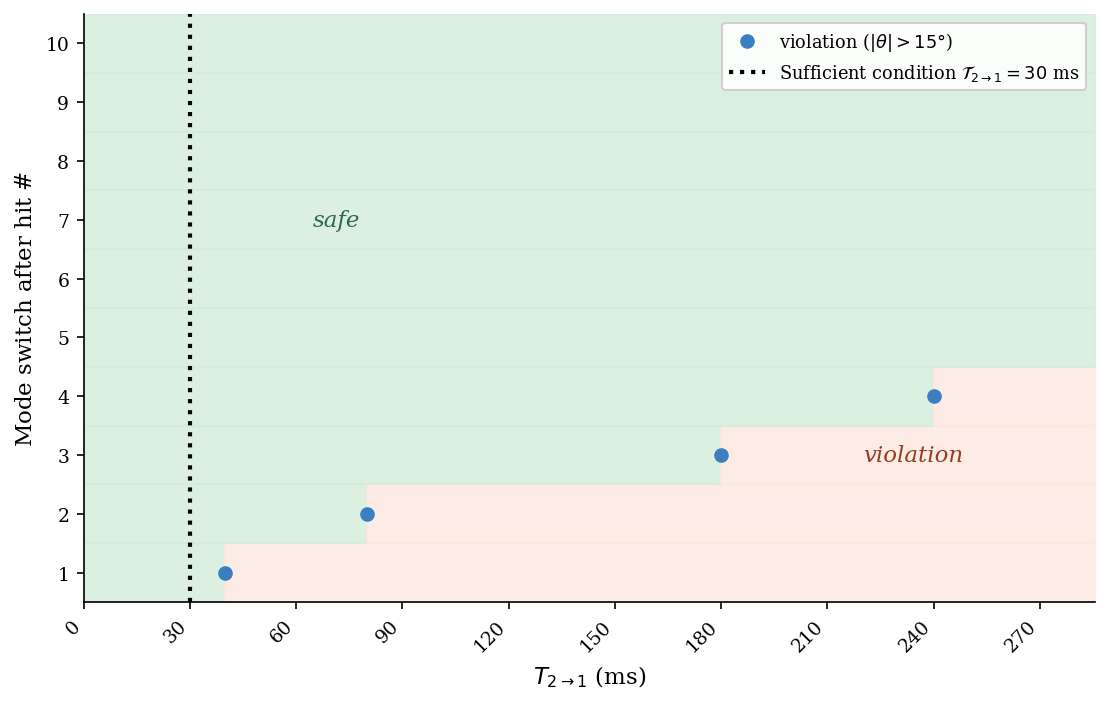

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         10,
    'axes.labelsize':    11,
    'axes.titlesize':    12,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('benchmark/switch_time_sweep_20260409_154707.csv')   # <-- replace with your CSV path
df['window_ms'] = (df['measured_window'] * 1000).round(1)

# ── Violation threshold ───────────────────────────────────────────────────────
# Use status column if CSV has Safe/Violated rows:
#   df['violated'] = df['status'] == 'Violated'
# Otherwise threshold on max_theta:
THRESH_DEG = 15.0
df['violated'] = df['max_theta'] > np.deg2rad(THRESH_DEG)

# ── Find boundary: for each hit_index, smallest window_ms with violated=True ──
hit_indices  = sorted(df['hit_index'].unique())
boundary_hit = []
boundary_win = []

for hit in hit_indices:
    sub      = df[df['hit_index'] == hit].sort_values('window_ms')
    violated = sub[sub['violated']]
    if not violated.empty:
        boundary_hit.append(float(hit))
        boundary_win.append(float(violated['window_ms'].min()))

boundary_hit = np.array(boundary_hit)
boundary_win = np.array(boundary_win)
bnd_lookup   = dict(zip(boundary_hit, boundary_win))

# ── Axis limits ───────────────────────────────────────────────────────────────
x_min = 0
x_max = df['window_ms'].max() * 1.02
y_min = min(hit_indices) - 0.5
y_max = max(hit_indices) + 0.5

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 4.8))

# ── Shading: row by row — no overlap possible ─────────────────────────────────
for hit in hit_indices:
    y0 = hit - 0.5
    y1 = hit + 0.5
    if hit in bnd_lookup:
        bx = bnd_lookup[hit]
        # Safe: left of first violation
        ax.fill_betweenx([y0, y1], x_min, bx,
                         color='#d4edda', alpha=0.8, zorder=1)
        # Violated: from first violation rightward
        ax.fill_betweenx([y0, y1], bx, x_max,
                         color='#fde8e0', alpha=0.8, zorder=1)
    else:
        # Entire row is safe — no violation found
        ax.fill_betweenx([y0, y1], x_min, x_max,
                         color='#d4edda', alpha=0.8, zorder=1)

# ── Boundary dots ─────────────────────────────────────────────────────────────
ax.plot(boundary_win, boundary_hit,
        'o', color='#3A7FBF', markersize=6, zorder=5,
        label=rf'violation ($|\theta| > {THRESH_DEG:.0f}°$)')

# ── Region labels ─────────────────────────────────────────────────────────────
ax.text(0.25, 0.65, 'safe',
        transform=ax.transAxes, fontsize=11,
        color='#2d6a4f', fontstyle='italic',
        ha='center', va='center', zorder=6)
ax.text(0.82, 0.25, 'violation',
        transform=ax.transAxes, fontsize=11,
        color='#993C1D', fontstyle='italic',
        ha='center', va='center', zorder=6)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xlabel(r'$T_{2\to 1}$ (ms)', fontsize=11)
ax.set_ylabel(r'Mode switch after hit $\#$', fontsize=11)
ax.set_yticks(hit_indices)
ax.set_ylim(y_min, y_max)
ax.axvline(
    30,
    color='black',
    linestyle=':',
    linewidth=2,
    label=r'Sufficient condition $\mathcal{T}_{2 \to 1} = 30$ ms'
)
nice_ticks = np.arange(0, x_max + 1, 30).astype(int)
ax.set_xticks(nice_ticks)
ax.set_xticklabels(nice_ticks, rotation=45, ha='right')
ax.set_xlim(0, x_max)

ax.legend(loc='best', fontsize=8.5, framealpha=0.9, edgecolor='#ccc')

# ── Save ──────────────────────────────────────────────────────────────────────
fig.tight_layout()
fig.savefig('/Users/srindhikrishna/myworks/thesis/thesis-report/scientific-thesis-template-main/figures/hm_switch_time_vs_angle_from_mode2.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('boundary_curve_clean.png', dpi=150, bbox_inches='tight')
plt.show()